$$
\Phi(R,z) = -4G \frac{{\sum}_0}{h} {\int_{-\infty}^\infty} \lambda(z) \, dz \int_0^\infty \text{sen}^{-1} \left( \frac{2a}{\sqrt{+}+\sqrt{-}} \right) a K_0(a/h) \, da
$$

$$
\sqrt{+} = \sqrt{z^2 + (a+R)^2}
\\
\\
\sqrt{-} = \sqrt{z^2 + (a-R)^2}
$$

$$
\lambda(z) = \text{sech}^2(z/z_0)
$$

In [ ]:
import numpy as np
from scipy.integrate import quad, quad_vec
from scipy.special import k0
import matplotlib.pyplot as plt

# Constantes en unidades recomendadas
G = 43007.1  # Constante gravitacional en unidades de 10^10 M⊙, kpc y Gyr

# Parámetros del disco
Md = 1.0      # Masa total del disco en unidades de 10^10 M⊙
h = 3.0       # Escala radial en kpc
z0 = 0.9      # Escala vertical en kpc
Sigma0 = Md / (2 * np.pi * h**2)  # Densidad superficial central
epsilon = 1e-6  # Pequeño término para evitar divisiones por cero


# Función lambda(z), restringiendo la integración a |z| < 5*z0
def lambda_z(z):
    return  np.cosh(z / z0)**-2

# Raíces para la integral
def sqrt_plus_minus(z, zp, a, R):
    sqrt_p = np.sqrt((z - zp)**2 + (a + R)**2 + epsilon)
    sqrt_m = np.sqrt((z - zp)**2 + (a - R)**2 + epsilon)
    return sqrt_p, sqrt_m

# Integrando con corrección para evitar valores fuera de [-1,1]
def integrand(a, z, zp, R):
    sqrt_p, sqrt_m = sqrt_plus_minus(z, zp, a, R)
    arcsin_arg = np.clip(2 * a / (sqrt_p + sqrt_m), -1.0, 1.0)
    return np.arcsin(arcsin_arg) * a * k0(a / h) if (a / h) > epsilon else k0(epsilon)

"""
def potential(R, z):
    def inner_integral(a, z_val, R_val):
        return integrand(a, z_val, z_val, R_val)  # Asegurar que zp = z_val

    def outer_integral(z_val, R_val):
        return lambda_z(z_val) * quad(lambda a: inner_integral(a, z_val, R_val), 0, 2*h, limit=100)[0]

    return (-4 * G * Sigma0 / h) * quad(lambda z_val: outer_integral(z_val, R), -z0*2, 2*z0, limit=100)[0]
"""
# Potencial gravitacional optimizado usando `quad_vec`
def potential(R, z):
    def inner_integral(a, z_val, R_val):
        return integrand(a,z_val, z_val, R_val)

    def outer_integral(z_val, R_val):
        inner_result, _ = quad_vec(inner_integral, 0, h, args=(z_val, R_val))
        return lambda_z(z_val) * inner_result
    
    outer_result, _ = quad_vec(outer_integral, -3*z0, 3*z0, args=(R,))
    return (-4 * G * Sigma0 / h) * outer_result

# Crear una cuadrícula de puntos en el plano (x, y, z=0)
x = np.linspace(-25, 25, 30)
y = np.linspace(-25, 25, 30)
X, Y = np.meshgrid(x, y)
R = np.sqrt(X**2 + Y**2)  # Radio en el plano (x, y)
Z = np.zeros_like(R)      # z = 0

# Calcular el potencial en el plano (x, y, z=0) usando vectorización
# Calcular el potencial en la rejilla
Phi_grid = np.zeros_like(R)
for i in range(R.shape[0]):
    for j in range(R.shape[1]):
        Phi_grid[i, j] = potential(R[i, j], Z[i, j])

# Crear una cuadrícula de puntos en el plano (x, y=0, z)
#z = np.linspace(-20, 20, 25)
#X, Z = np.meshgrid(x, z)
#R = np.abs(X)  # Radio en el plano (x, y=0)

# Calcular el potencial en el plano (x, y=0, z)
#Phi_xz = np.vectorize(potential)(R, Z)



# Graficar en el plano (x, y=0, z)
#plt.figure(figsize=(10, 5))
#plt.contourf(X, Z, np.log10(-Phi_xz), levels=50, cmap='viridis')
#plt.colorbar(label='log10(-Potencial)')
#plt.xlabel('x (kpc)')
#plt.ylabel('z (kpc)')
#plt.title('Curvas equipotenciales en el plano (x, y=0, z)')
#plt.show()



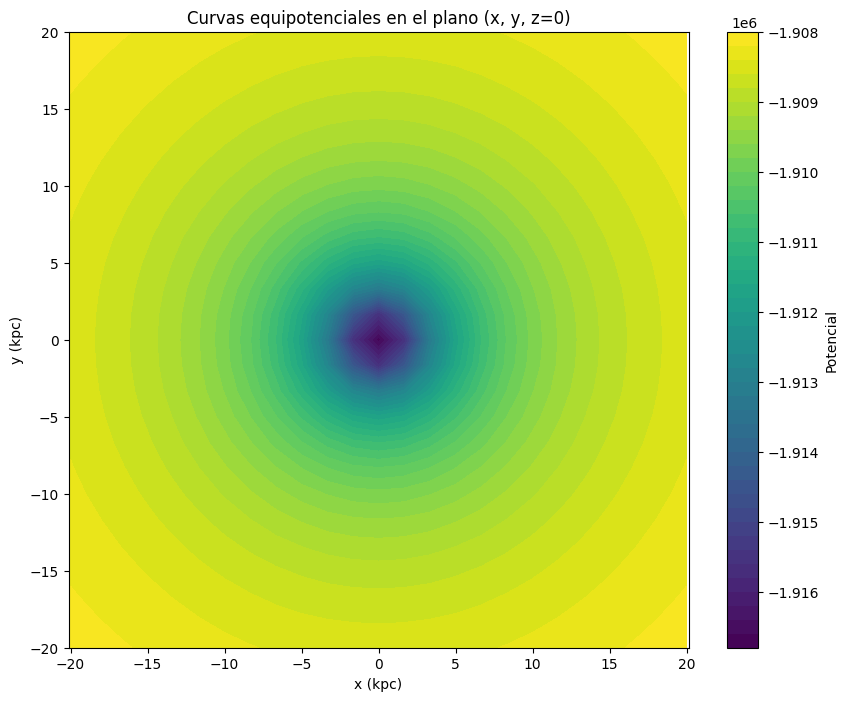

In [78]:
# Graficar en el plano (x, y, z=0)
plt.figure(figsize=(10, 8))
plt.contourf(X, Y, Phi_grid, levels=50, cmap='viridis')
plt.colorbar(label='Potencial')
plt.xlabel('x (kpc)')
plt.ylabel('y (kpc)')
plt.axis('equal')
plt.title('Curvas equipotenciales en el plano (x, y, z=0)')
plt.show()

In [198]:
import numpy as np
#from scipy.integrate import quad, quad_vec
import scipy.integrate as spi
from scipy.special import k0
import matplotlib.pyplot as plt

# Constantes en unidades recomendadas
G = 43007.1  # Constante gravitacional en unidades de 10^10 M⊙, kpc y Gyr

# Parámetros del disco
Md = 6.0      # Masa total del disco en unidades de 10^10 M⊙
h = 2.5       # Escala radial en kpc
z0 = 0.9      # Escala vertical en kpc
Sigma0 = Md / (2 * np.pi * h**2)  # Densidad superficial central
epsilon = 1e-6  # Pequeño término para evitar divisiones por cero


# Función lambda(z), restringiendo la integración a |z| < 5*z0
def lambda_z(z):
    return  np.cosh(z / z0)**-2

# Raíces para la integral
def sqrt_plus_minus(z, zp, a, R):
    sqrt_p = np.sqrt((z - zp)**2 + (a + R)**2 + epsilon)
    sqrt_m = np.sqrt((z - zp)**2 + (a - R)**2 + epsilon)
    return sqrt_p, sqrt_m

# Integrando con corrección para evitar valores fuera de [-1,1]
def integrand(a, z, zp, R):
    sqrt_p, sqrt_m = sqrt_plus_minus(z, zp, a, R)
    arcsin_arg = np.clip(2 * a / (sqrt_p + sqrt_m), -1.0, 1.0)
    return lambda_z(z)*np.arcsin(arcsin_arg) * a * k0(a / h) if (a / h) > epsilon else k0(epsilon)

def potential(R, z):
    try:
        integral_result, _ = spi.dblquad(
            integrand,  # Función a integrar
            0, 5*h,  # Límites para a (0 a 10 veces h)
            lambda a: -10*z0, lambda a: 10*z0,  # Límites para zp (-5z0 a 5z0)
            args=(R, z),  # Argumentos adicionales (R, z)
            epsabs=1e-4, epsrel=1e-4  # Ajustamos precisión
        )
        return - (4 * G * Sigma0 / h) * integral_result
    except Exception as e:
        print(f"Error en la integración: {e}")
        return np.nan  # En caso de error, devolver NaN
    
    # Crear una cuadrícula de puntos en el plano (x, y, z=0)
x = np.linspace(-20, 20, 50)
y = np.linspace(-20, 20, 50)
X, Y = np.meshgrid(x, y)
R = np.sqrt(X**2 + Y**2)  # Radio en el plano (x, y)
Z = np.zeros_like(R)      # z = 0

# Calcular el potencial en el plano (x, y, z=0) usando vectorización
# Calcular el potencial en la rejilla
Phi_grid = np.zeros_like(R)
for i in range(R.shape[0]):
    for j in range(R.shape[1]):
        Phi_grid[i, j] = potential(R[i, j], Z[i, j])

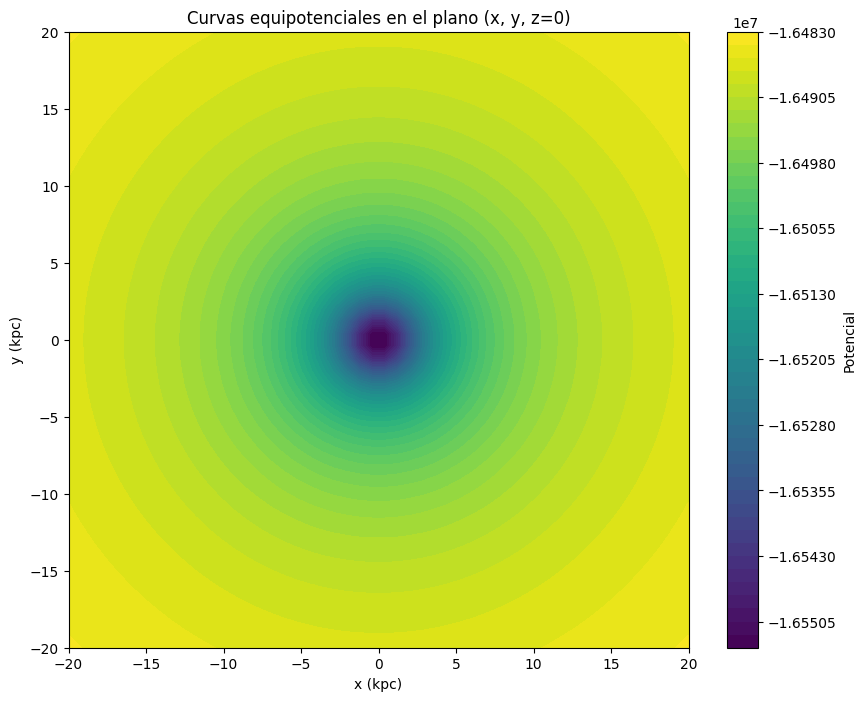

In [184]:
# Graficar en el plano (x, y, z=0)
plt.figure(figsize=(10, 8))
plt.contourf(X, Y, Phi_grid, levels=50, cmap='viridis')
plt.colorbar(label='Potencial')
plt.xlabel('x (kpc)')
plt.ylabel('y (kpc)')
#plt.axis('equal')
plt.title('Curvas equipotenciales en el plano (x, y, z=0)')
plt.show()

In [185]:
# Crear una cuadrícula de puntos en el plano (x, y=0, z)
z = np.linspace(-20, 20, 50)
X, Z = np.meshgrid(x, z)
R = np.abs(X)  # Radio en el plano (x, y=0)

# Calcular el potencial en el plano (x, y=0, z)
#Phi_xz = np.vectorize(potential)(R, Z)

Phi_xz = np.zeros_like(R)
for i in range(R.shape[0]):
    for j in range(R.shape[1]):
        Phi_xz[i, j] = potential(R[i, j], Z[i, j])



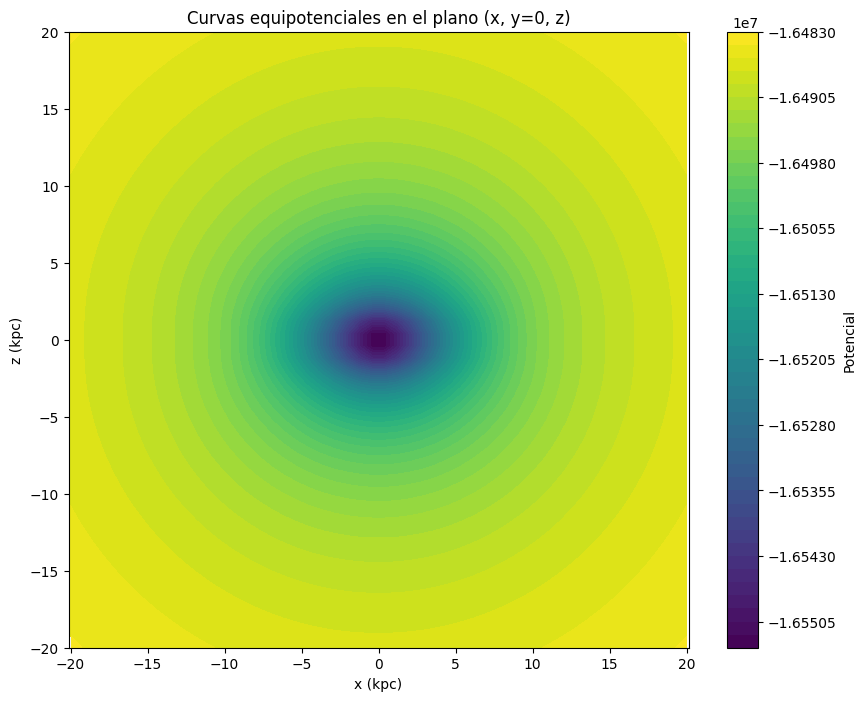

In [188]:
# Graficar en el plano (x, y=0, z)
plt.figure(figsize=(10, 8))
plt.contourf(Z, X, Phi_xz, levels=50, cmap='viridis')
plt.colorbar(label='Potencial')
plt.axis('equal')
plt.xlabel('x (kpc)')
plt.ylabel('z (kpc)')
plt.title('Curvas equipotenciales en el plano (x, y=0, z)')
plt.show()

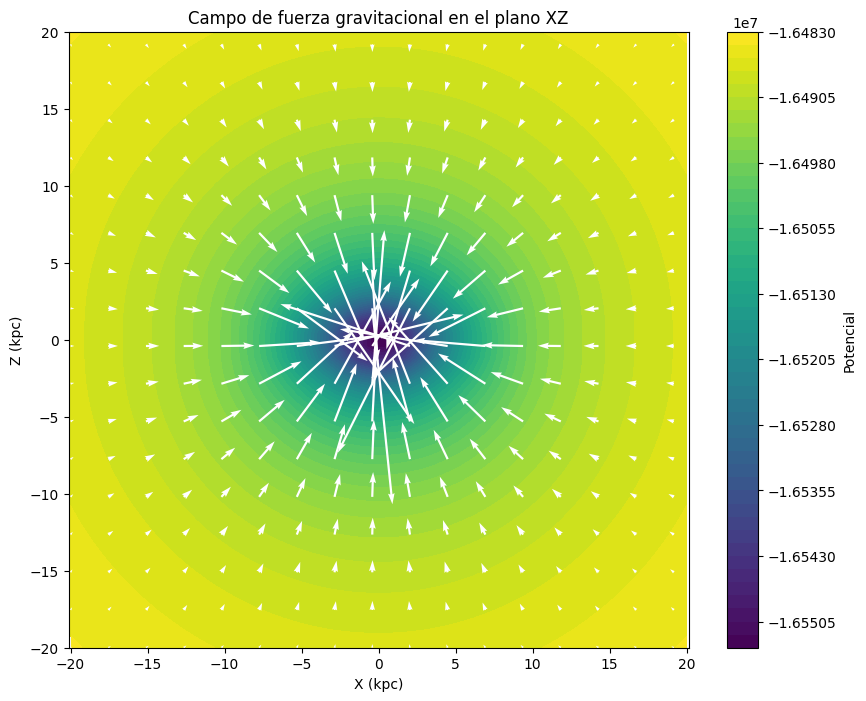

In [228]:
# Definir diferencias finitas
dR = np.abs(R[0,1] - R[0,0])  # Paso en R
dZ = np.abs(Y[1,0] - Y[0,0])  # Paso en Z

# Calcular las derivadas parciales usando diferencias centradas
g_R = - (np.roll(Phi_xz, -1, axis=1) - np.roll(Phi_xz, 1, axis=1)) / (2 * dR)  # Derivada en R
g_Z = - (np.roll(Phi_xz, -1, axis=0) - np.roll(Phi_xz, 1, axis=0)) / (2 * dZ)  # Derivada en Z

# Graficar el campo de fuerza con flechas (quiver)
plt.figure(figsize=(10, 8))
plt.contourf(Y, X, Phi_xz, levels=50, cmap='viridis')  # Contorno del potencial
plt.colorbar(label='Potencial')

# Dibujar el campo de fuerza
#plt.quiver(X[20:25,20:25], Z[20:25,20:25], g_R[20:25,20:25], g_Z[20:25,20:25], color='white', scale=700)
#plt.quiver(X, Z, g_R, g_Z, color='white', scale=15000)

step = 3
plt.quiver(Z[::step, ::step], X[::step, ::step], g_Z[::step, ::step], g_R[::step, ::step], 
           color='white', scale=40000)

plt.xlabel('X (kpc)')
plt.ylabel('Z (kpc)')
plt.axis('equal')
plt.title('Campo de fuerza gravitacional en el plano XZ')
plt.show()

In [194]:
import numpy as np
import matplotlib.pyplot as plt

# --- Supongamos que ya tienes calculado el potencial en el plano XY ---
# Este potencial se obtuvo usando tu función 'potential' (con z=0)
# y generaste Phi_grid en una malla definida por X, Y.
# Por ejemplo:
# x = np.linspace(-20, 20, 25)
# y = np.linspace(-20, 20, 25)
# X, Y = np.meshgrid(x, y)
# R_grid = np.sqrt(X**2 + Y**2)
# Z = np.zeros_like(R_grid)
# Phi_grid = np.zeros_like(R_grid)
# for i in range(R_grid.shape[0]):
#     for j in range(R_grid.shape[1]):
#         Phi_grid[i, j] = potential(R_grid[i, j], Z[i, j])
# ---------------------------------------------------------------

# 1. Calcular la derivada radial usando la simetría axial.
#   Evaluamos el potencial a lo largo del eje x (donde y=0, R=|x|).

# Usamos la mitad positiva, ya que el potencial es simétrico.
x_axis = np.linspace(0, 20, 50)  # Ajusta el rango y número de puntos según necesites.
Phi_axis = np.array([potential(np.abs(x), 0) for x in x_axis])

# 2. Aproximamos dPhi/dR usando diferencias finitas unidimensionales.
dPhi_dR_axis = np.gradient(Phi_axis, x_axis)

# 3. Para cada punto (x,y) de la malla, obtenemos R y usamos interpolación
#    para asignar el valor de dPhi/dR.
R_vals = np.sqrt(X**2 + Y**2)
# Interpolamos dPhi/dR para cada valor de R en la cuadrícula.
dPhi_dR_grid = np.interp(R_vals.flatten(), x_axis, dPhi_dR_axis).reshape(R_vals.shape)

# 4. Calcular las componentes del campo de fuerza en coordenadas cartesianas.
# Se evita la división por cero agregando un pequeño término.
F_x = -dPhi_dR_grid * (X / (R_vals + 1e-6))
F_y = -dPhi_dR_grid * (Y / (R_vals + 1e-6))






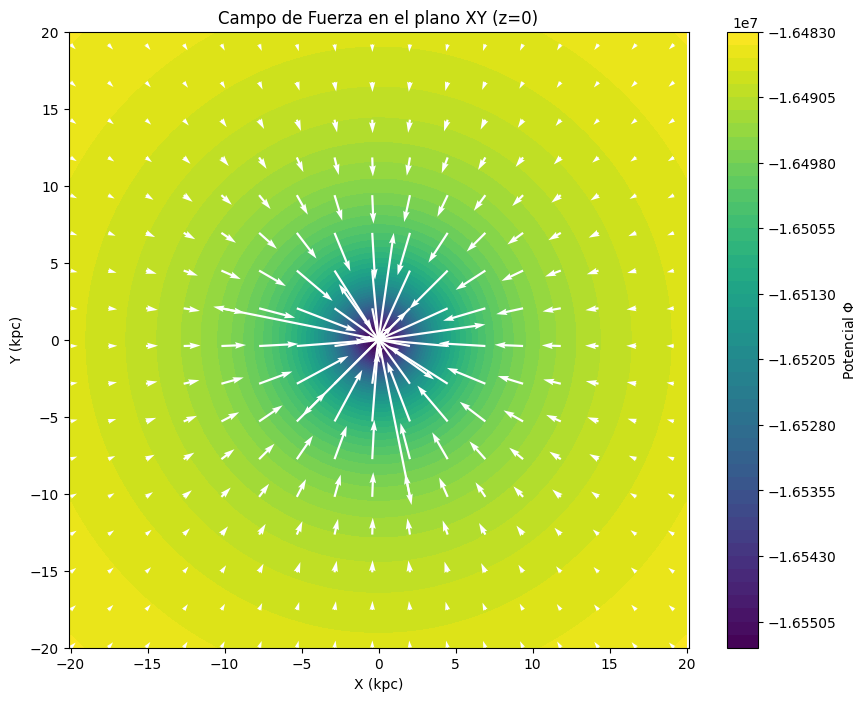

In [196]:
# Graficar el campo de fuerza con quiver.
# 5. Graficar el potencial y el campo de fuerza.
plt.figure(figsize=(10, 8))
# Graficar contornos del potencial.
plt.contourf(X, Y, Phi_grid, levels=50, cmap='viridis')
plt.colorbar(label='Potencial $\Phi$')
step = 3
plt.quiver(X[::step, ::step], Y[::step, ::step], F_x[::step, ::step], F_y[::step, ::step], color='white', scale=40000)

plt.xlabel('X (kpc)')
plt.ylabel('Y (kpc)')
plt.title('Campo de Fuerza en el plano XY (z=0)')
plt.axis('equal')
plt.show()

In [140]:
!pip install galpy -q
!pip install astropy -q


[notice] A new release of pip is available: 24.3.1 -> 25.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip

[notice] A new release of pip is available: 24.3.1 -> 25.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


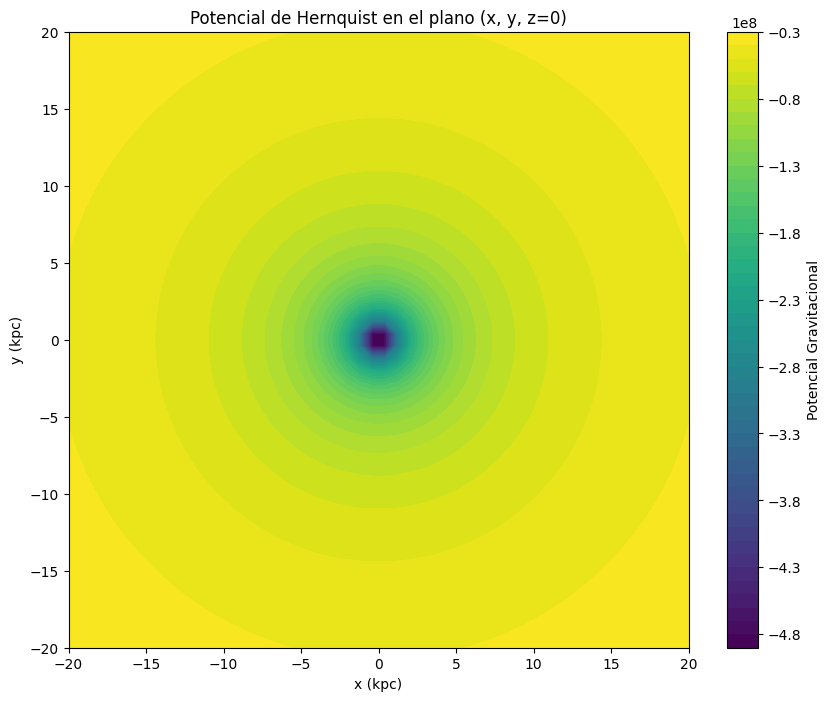

In [210]:
import numpy as np
import matplotlib.pyplot as plt
from astropy import units
from galpy.potential import HernquistPotential, evaluatePotentials

# Definir el potencial de Hernquist
hernquist_pot = HernquistPotential(amp=0.1e10, a=0.5)  # Masa unitaria y escala a=1 kpc

# Crear una cuadrícula en el plano (x, y, z=0)
x = np.linspace(-20, 20, 50)  # kpc
y = np.linspace(-20, 20, 50)  # kpc
X, Y = np.meshgrid(x, y)

# Convertir coordenadas cartesianas a coordenadas esféricas
R = np.sqrt(X**2 + Y**2)  # r en coordenadas esféricas

# Evaluar el potencial en la malla
Phi_grid_bulbo1 = evaluatePotentials(hernquist_pot, R,0)
Phi_total_1 = Phi_grid_bulbo1 + Phi_grid

# Graficar el potencial
plt.figure(figsize=(10, 8))
plt.contourf(X, Y, Phi_total_1, levels=50, cmap='viridis')
plt.colorbar(label='Potencial Gravitacional')
plt.xlabel('x (kpc)')
plt.ylabel('y (kpc)')
plt.title('Potencial de Hernquist en el plano (x, y, z=0)')
plt.show()


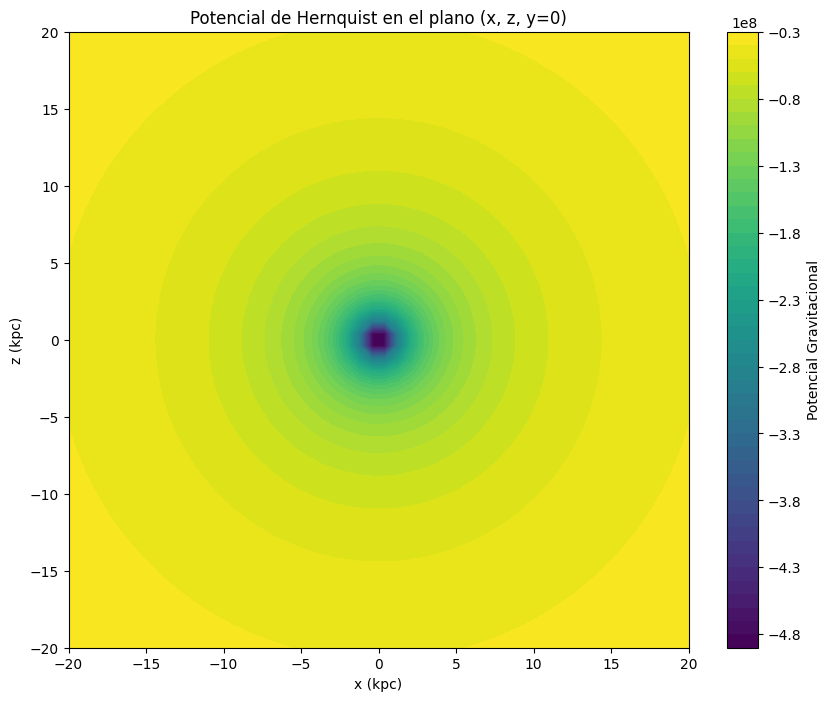

In [214]:
# Definir el potencial de Hernquist
hernquist_pot = HernquistPotential(amp=0.1e10, a=0.5)  # Masa unitaria y escala a=1 kpc

# Crear una cuadrícula en el plano (x, y, z=0)
x = np.linspace(-20, 20, 50)  # kpc
z = np.linspace(-20, 20, 50)  # kpc
R, Z = np.meshgrid(x, z)


# Evaluar el potencial en la malla
Phi_grid_bulbo2 = evaluatePotentials(hernquist_pot, R,Z)
Phi_total_2 = Phi_grid_bulbo2 + Phi_xz

# Graficar el potencial
plt.figure(figsize=(10, 8))
plt.contourf(X, Y, Phi_total_2, levels=50, cmap='viridis')
plt.colorbar(label='Potencial Gravitacional')
plt.xlabel('x (kpc)')
plt.ylabel('z (kpc)')
plt.title('Potencial de Hernquist en el plano (x, z, y=0)')
plt.show()

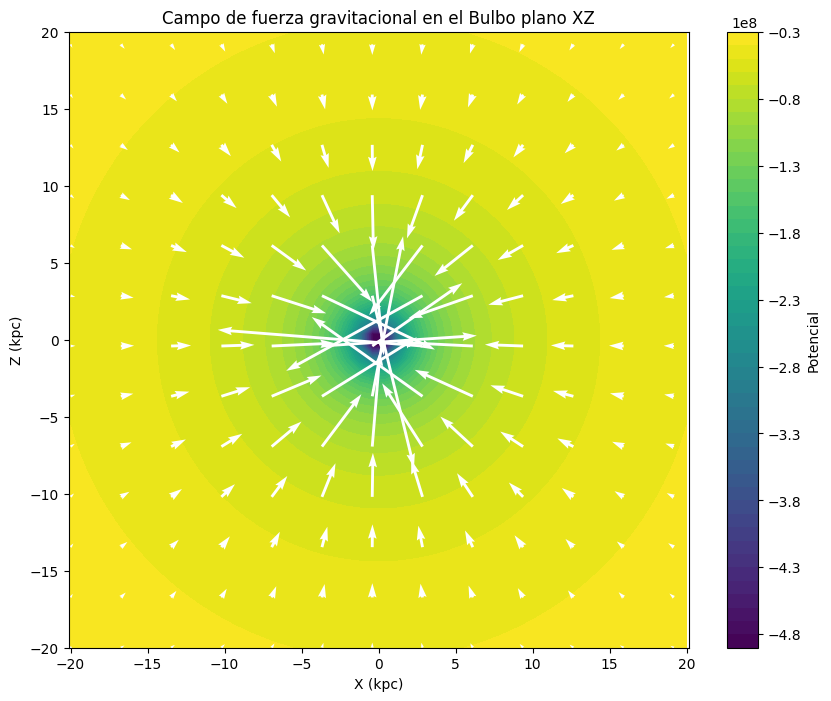

In [224]:
# Definir diferencias finitas
dR = np.abs(R[0,1] - R[0,0])  # Paso en R
dZ = np.abs(Y[1,0] - Y[0,0])  # Paso en Z

# Calcular las derivadas parciales usando diferencias centradas
g_R = - (np.roll(Phi_xz, -1, axis=1) - np.roll(Phi_xz, 1, axis=1)) / (2 * dR)  # Derivada en R
g_Z = - (np.roll(Phi_xz, -1, axis=0) - np.roll(Phi_xz, 1, axis=0)) / (2 * dZ)  # Derivada en Z

# Graficar el campo de fuerza con flechas (quiver)
plt.figure(figsize=(10, 8))
plt.contourf(X, Y, Phi_total_2, levels=50, cmap='viridis')  # Contorno del potencial
plt.colorbar(label='Potencial')

# Dibujar el campo de fuerza
#plt.quiver(X[20:25,20:25], Z[20:25,20:25], g_R[20:25,20:25], g_Z[20:25,20:25], color='white', scale=700)
#plt.quiver(X, Z, g_R, g_Z, color='white', scale=15000)

step = 4
plt.quiver(X[::step, ::step], Z[::step, ::step], g_R[::step, ::step], g_Z[::step, ::step], 
           color='white', scale=30000)

plt.xlabel('X (kpc)')
plt.ylabel('Z (kpc)')
plt.axis('equal')
plt.title('Campo de fuerza gravitacional en el Bulbo plano XZ')
plt.show()

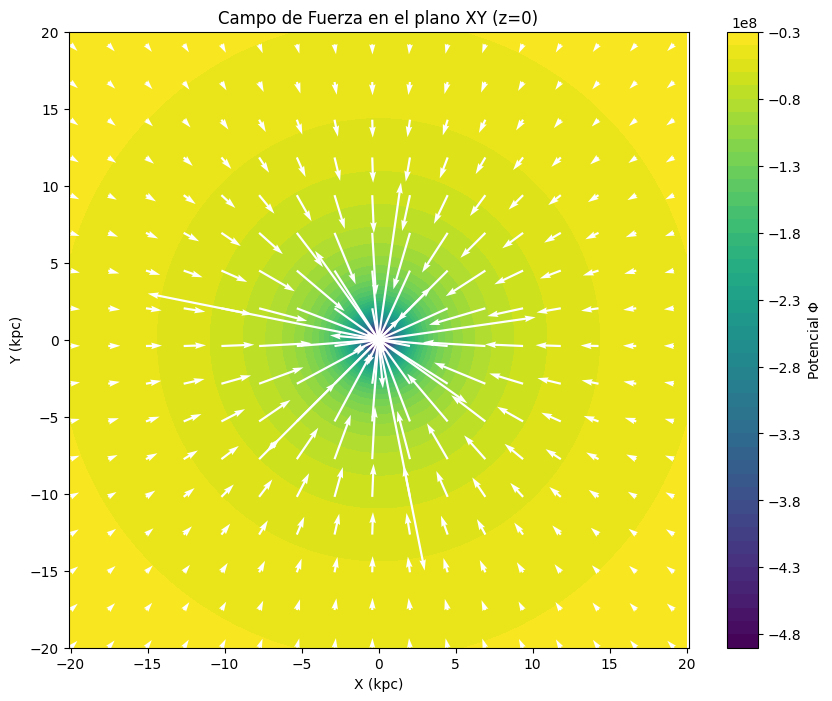

In [226]:
# Graficar el campo de fuerza con quiver.
# 5. Graficar el potencial y el campo de fuerza.
plt.figure(figsize=(10, 8))
# Graficar contornos del potencial.
plt.contourf(X, Y, Phi_total_1, levels=50, cmap='viridis')
plt.colorbar(label='Potencial $\Phi$')
step = 3
plt.quiver(X[::step, ::step], Y[::step, ::step], F_x[::step, ::step], F_y[::step, ::step], color='white', scale=30000)

plt.xlabel('X (kpc)')
plt.ylabel('Y (kpc)')
plt.title('Campo de Fuerza en el plano XY (z=0)')
plt.axis('equal')
plt.show()